In [1]:
from model import common
import torch
import numpy as np
import yaml
import data
import utils
from tqdm import tqdm
import os
import pandas as pd
import copy
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
with open(os.path.join("yaml/test.yaml"), "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

In [3]:
from model.unet import make_model
# from model.dncnn import make_model

config["model"]["name"], config["model"]["level"] = "UNet", "B"
base = config["model"]["name"].lower() + "-" + config["model"]["level"]
load_names = [
    base,
    base + "+NADD1",
    base + "+COV1_k5",
    base + "+OURS1_g2_k5",
]

config["model"]["pooling"] = True
config["model"]["num_blocks"], config["model"]["groups"], config["model"]["scale"] = [2, 2, 2, 2, 2], [2, 2, 2, 2, 2], 4
config["N_augment"]["patch_size"], config["N_augment"]["kernel_size"] = 5, 5

configs_list = [
    {"name": "Vanilla", "N_cov": False, "N_ch": 0, "backbone": "conv"},
    {"name": "+NADD", "N_cov": False, "N_ch": 1, "backbone": "conv"},
    {"name": "+COV", "N_cov": True, "N_ch": 1, "patch_size": 5, "kernel_size": 5, "backbone": "conv"},
    {"name": "+ENCORE", "N_cov": True, "N_ch": 1, "patch_size": 5, "kernel_size": 5, "backbone": "core"},
]

models = []
model_names = []
for i, cfg_item in enumerate(configs_list):
    cfg = copy.deepcopy(config)
    cfg["N_augment"].update({"N_cov": cfg_item["N_cov"], "N_ch": cfg_item["N_ch"]})
    cfg["model"]["backbone"] = cfg_item["backbone"]
    if cfg_item["N_cov"]:
        cfg["N_augment"].update({"patch_size": cfg_item["patch_size"], "kernel_size": cfg_item["kernel_size"]})

    model = make_model(cfg).cuda()
    
    load_name = load_names[i]
    model_names.append(load_name)
    
    state_dict = torch.load(os.path.join("trained_models", load_name + ".pt"), map_location=torch.device(0))
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    models.append(model)

model loaded!: UNet-B+conv
[0.0, 0.0, 0.0, 0.0] 0.0 [0.0, 0.0, 0.0, 0.0]
model loaded!: UNet-B+conv
[0.0, 0.0, 0.0, 0.0] 0.0 [0.0, 0.0, 0.0, 0.0]
model loaded!: UNet-B+conv
Covariance Configs:  5 5
[0.0, 0.0, 0.0, 0.0] 0.0 [0.0, 0.0, 0.0, 0.0]
model loaded!: UNet-B+core
Covariance Configs:  5 5
[0.0, 0.0, 0.0, 0.0] 0.0 [0.0, 0.0, 0.0, 0.0]


In [4]:
config["dataset"]["dose_level"] = 0.1
config["dataset"]["generation"] = "cornish"
config["dataset"]["geometry"] = {
    "num_view": 1024,
    "num_det": 736,
    "det_interval": 1.2858,
    "sod": 595,
    "sdd": 1085.6
}
clean = torch.from_numpy(np.load("for_demo/clean.npy")).cuda()
noisy = torch.from_numpy(np.load("for_demo/noisy.npy")).cuda()
metadata = torch.from_numpy(np.load("for_demo/metadata.npy")).cuda()
reconstruction = common.NoiseRecon(config).eval()

In [5]:
output_img = np.zeros((6, 1, 512, 512), dtype=np.float32)
with torch.no_grad():
    input, noise, recon = reconstruction(metadata, clean, noisy, N_ch=1)
    output_img[0, 0, :, :] = input.squeeze().cpu().numpy()
    output_img[-1, 0, :, :] = recon.squeeze().cpu().numpy()
    input = utils.normalize(input)
    noise = utils.normalize(noise, slope=100, intercept=0)

    for j, model in enumerate(models):
        output = model(input.clone(), noise.clone())
        output = utils.denormalize(output)
        output_img[j+1, 0, :, :] = output.squeeze().cpu().numpy()

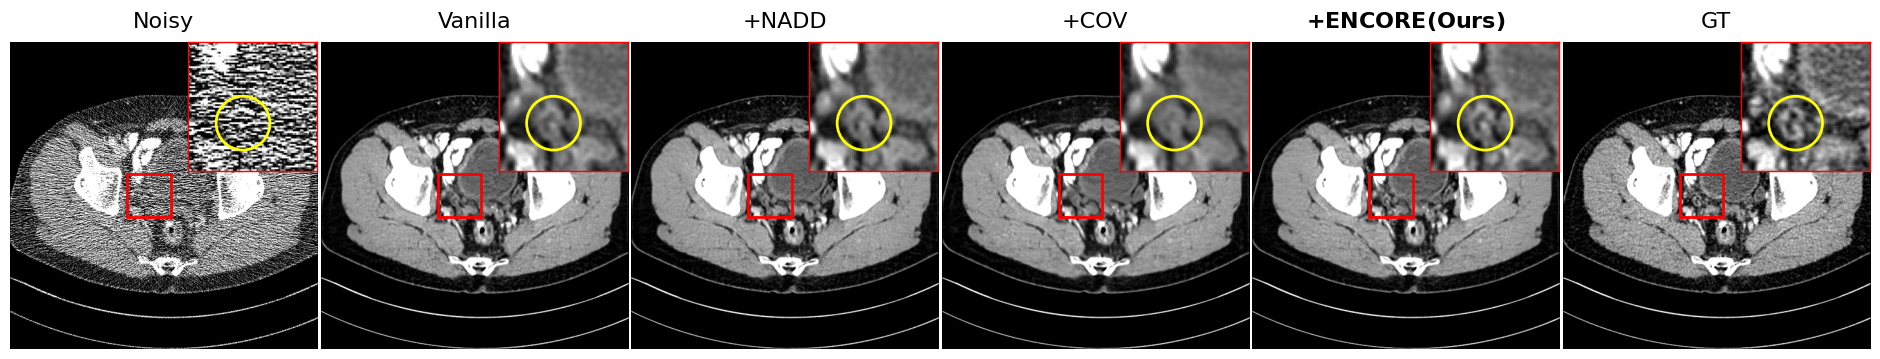

In [7]:
disp_window = [-120, 180]
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches

labels = ["Noisy", "Vanilla", "+NADD", "+COV", r"$\bf{+ENCORE (Ours)}$", "GT"]
x_idx, y_idx, roi_size = 195, 220, 72
circle_center, circle_radius = [30, 45], 15

def crop_roi(img):
    return img[y_idx:y_idx+roi_size, x_idx:x_idx+roi_size]

fig, axs = plt.subplots(1, 6, figsize=(4 * 6, 4.5))
for i in range(len(output_img)):
    # Full images with ROI box and inset zoomed-in ROI
    axs[i].imshow(output_img[i, 0], cmap="gray", vmin=disp_window[0], vmax=disp_window[1])
    rect = patches.Rectangle((x_idx, y_idx), roi_size, roi_size, linewidth=2, edgecolor='r', facecolor='none')
    axs[i].add_patch(rect)
    axs[i].set_title(labels[i], fontsize=16, pad=10)
    axs[i].axis('off')
    
    # Inset zoomed ROI in the corner
    roi_img = crop_roi(output_img[i, 0])
    ax_inset = inset_axes(axs[i], width="42%", height="42%", loc="upper right", borderpad=0)
    ax_inset.imshow(roi_img, cmap="gray", vmin=disp_window[0], vmax=disp_window[1])
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    for spine in ax_inset.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(1)

    circle = patches.Circle((circle_center[0], circle_center[1]), radius=circle_radius, linewidth=2, edgecolor='yellow', facecolor='none')
    ax_inset.add_patch(circle)
plt.subplots_adjust(wspace=0.01)